<a href="https://colab.research.google.com/github/hongocphuongnhu/TH_Deep_Learning/blob/main/THDeep_Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# BÀI 1: CIFAR-10
# 1. Nạp dữ liệu CIFAR-10
(X_train_cf, y_train_cf), (X_test_cf, y_test_cf) = keras.datasets.cifar10.load_data()

CLASS_NAMES_CIFAR = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']
NUM_CLASSES = 10

print('X_train shape:', X_train_cf.shape)  # (50000, 32, 32, 3)
print('X_test shape :', X_test_cf.shape)   # (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
X_train shape: (50000, 32, 32, 3)
X_test shape : (10000, 32, 32, 3)


/tmp/ipykernel_1185/462781401.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(CLASS_NAMES_CIFAR[int(y_train_cf[i])], fontsize=11)


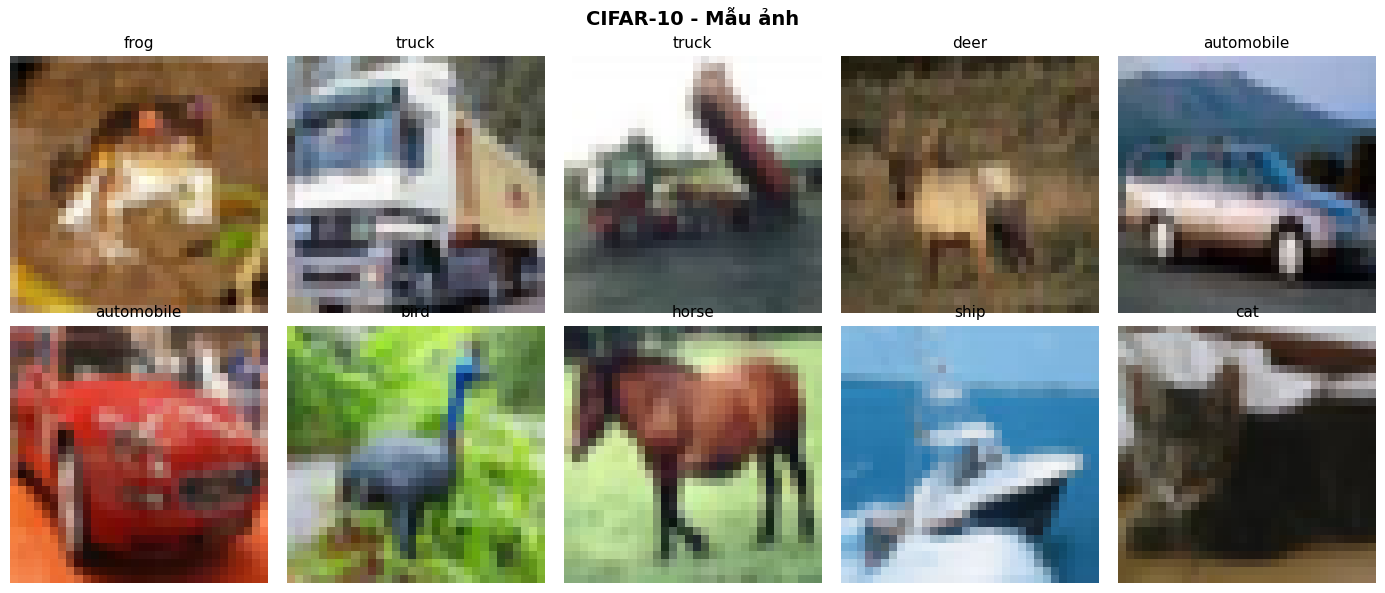

In [ ]:
# 2. Trực quan hóa một số ảnh mẫu
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train_cf[i])
    ax.set_title(CLASS_NAMES_CIFAR[int(y_train_cf[i])], fontsize=11)
    ax.axis('off')
plt.suptitle('CIFAR-10 - Mẫu ảnh', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 3. Tiền xử lý dữ liệu
X_train_cf = X_train_cf.astype('float32') / 255.0
X_test_cf  = X_test_cf.astype('float32') / 255.0

y_train_cf_cat = keras.utils.to_categorical(y_train_cf, NUM_CLASSES)
y_test_cf_cat  = keras.utils.to_categorical(y_test_cf,  NUM_CLASSES)

In [ ]:
# 4. Xây dựng mô hình CNN cho CIFAR-10
def build_cifar_model():
    model = Sequential([
        Input(shape=(32, 32, 3)),

        # Block 1
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Fully connected
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model_cf = build_cifar_model()
model_cf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# 5. Compile & Huấn luyện
model_cf.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_cf = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)
]

history_cf = model_cf.fit(
    X_train_cf, y_train_cf_cat,
    batch_size=64,
    epochs=30,
    validation_split=0.1,
    callbacks=callbacks_cf,
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.3691 - loss: 1.7438 - val_accuracy: 0.4654 - val_loss: 1.5205 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5223 - loss: 1.3248 - val_accuracy: 0.6264 - val_loss: 1.0603 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5993 - loss: 1.1448 - val_accuracy: 0.6140 - val_loss: 1.1616 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6423 - loss: 1.0208 - val_accuracy: 0.6814 - val_loss: 0.9904 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6762 - loss: 0.9426 - val_accuracy: 0.7150 - val_loss: 0.8230 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6983 - loss: 0.8756 - val_accuracy: 0.7074 - val_loss: 0.8882 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7182 - loss: 0.8233

[CIFAR-10] Test Loss    : 0.4968
[CIFAR-10] Test Accuracy: 84.44%


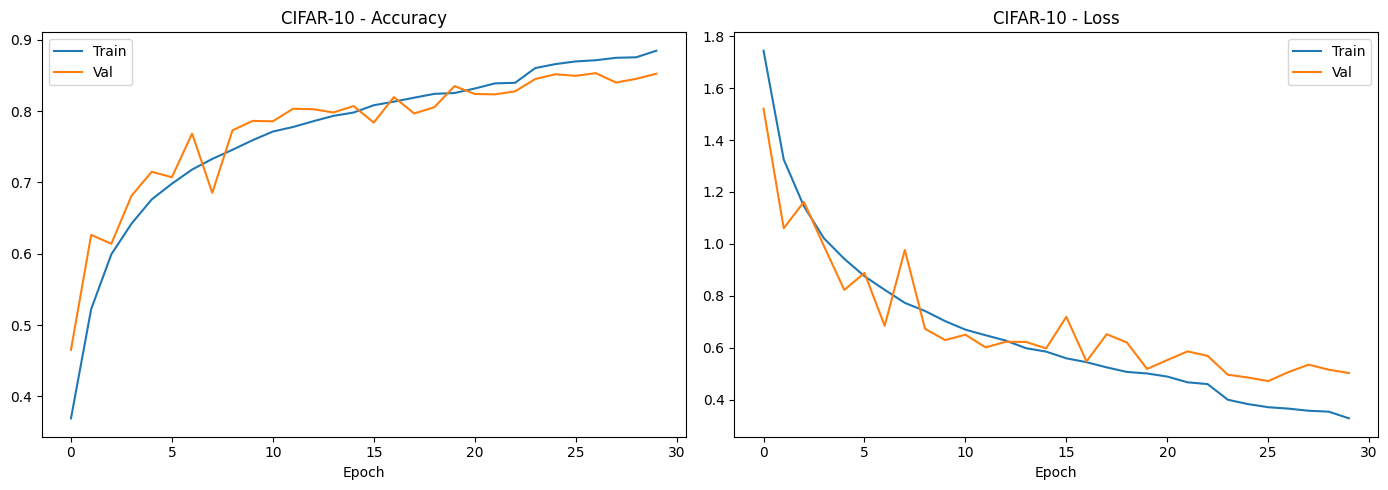

In [ ]:
# 6. Đánh giá & Vẽ biểu đồ
score_cf = model_cf.evaluate(X_test_cf, y_test_cf_cat, verbose=0)
print(f'[CIFAR-10] Test Loss    : {score_cf[0]:.4f}')
print(f'[CIFAR-10] Test Accuracy: {score_cf[1]*100:.2f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_cf.history['accuracy'],     label='Train')
ax1.plot(history_cf.history['val_accuracy'], label='Val')
ax1.set_title('CIFAR-10 - Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history_cf.history['loss'],     label='Train')
ax2.plot(history_cf.history['val_loss'], label='Val')
ax2.set_title('CIFAR-10 - Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step


/tmp/ipykernel_1185/3558863466.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label  = CLASS_NAMES_CIFAR[int(y_test_cf[i])]


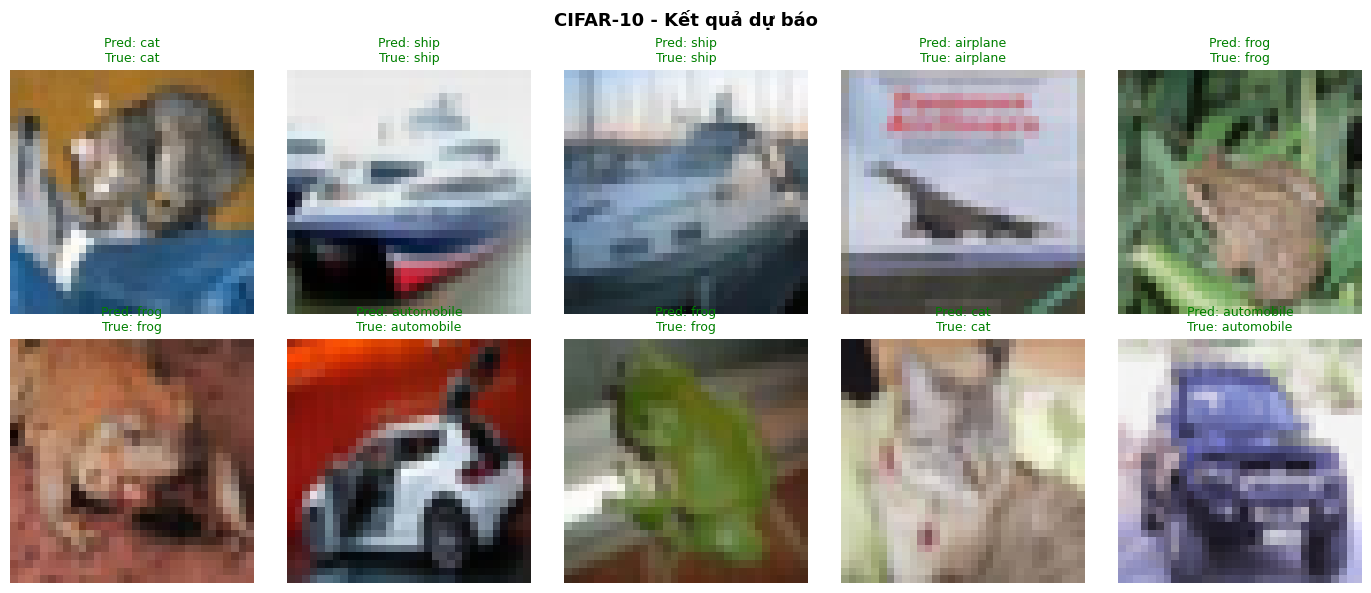

In [ ]:
# 7. Dự báo một số ảnh test
predictions_cf = model_cf.predict(X_test_cf[:10])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_cf[i])
    pred_label  = CLASS_NAMES_CIFAR[np.argmax(predictions_cf[i])]
    true_label  = CLASS_NAMES_CIFAR[int(y_test_cf[i])]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'Pred: {pred_label}\nTrue: {true_label}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 - Kết quả dự báo', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE_CD = (128, 128)
BATCH_SIZE = 32
TRAIN_DIR = '/content/drive/MyDrive/CatDog/training_set'
TEST_DIR  = '/content/drive/MyDrive/CatDog/test_set'


train_gen = ImageDataGenerator(rescale=1./255, rotation_range=20,
                                width_shift_range=0.1, height_shift_range=0.1,
                                horizontal_flip=True)
test_gen  = ImageDataGenerator(rescale=1./255)

ds_train_cd = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE_CD,
                                            batch_size=BATCH_SIZE, class_mode='binary')
ds_test_cd  = test_gen.flow_from_directory(TEST_DIR,   target_size=IMG_SIZE_CD,
                                            batch_size=BATCH_SIZE, class_mode='binary')
CLASS_NAMES_CD = list(ds_train_cd.class_indices.keys())
print('Classes:', CLASS_NAMES_CD)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.
Classes: ['cats', 'dogs']


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, Dense, MaxPool2D, Flatten, Dropout, BatchNormalization

def build_catdog_model():
    model = Sequential([
        Input(shape=(*IMG_SIZE_CD, 3)),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary: cat=0, dog=1
    ])
    return model

model_cd = build_catdog_model()
model_cd.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,265 (32.36 MB)

 Trainable params: 8,482,817 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_cd.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_cd = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3)
]

history_cd = model_cd.fit(
    ds_train_cd,
    epochs=10,
    validation_data=ds_test_cd,
    callbacks=callbacks_cd,
    verbose=1
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 457s 2s/step - accuracy: 0.5879 - loss: 1.4443 - val_accuracy: 0.5082 - val_loss: 2.0639 - learning_rate: 0.0010
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 78s 311ms/step - accuracy: 0.6271 - loss: 0.6374 - val_accuracy: 0.6574 - val_loss: 1.4133 - learning_rate: 0.0010
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 78s 310ms/step - accuracy: 0.6481 - loss: 0.6146 - val_accuracy: 0.6718 - val_loss: 0.6652 - learning_rate: 0.0010
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 79s 315ms/step - accuracy: 0.6633 - loss: 0.5982 - val_accuracy: 0.6980 - val_loss: 0.5938 - learning_rate: 0.0010
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 325ms/step - accuracy: 0.6777 - loss: 0.5883 - val_accuracy: 0.7242 - val_loss: 0.5374 - learning_rate: 0.0010
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 79s 313ms/step - accuracy: 0.7016 - loss: 0.5819 - val_accuracy: 0.6935 - val_loss: 0.6190 - learning_rate: 0.0010
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 80s 317ms/step - accuracy: 0.696

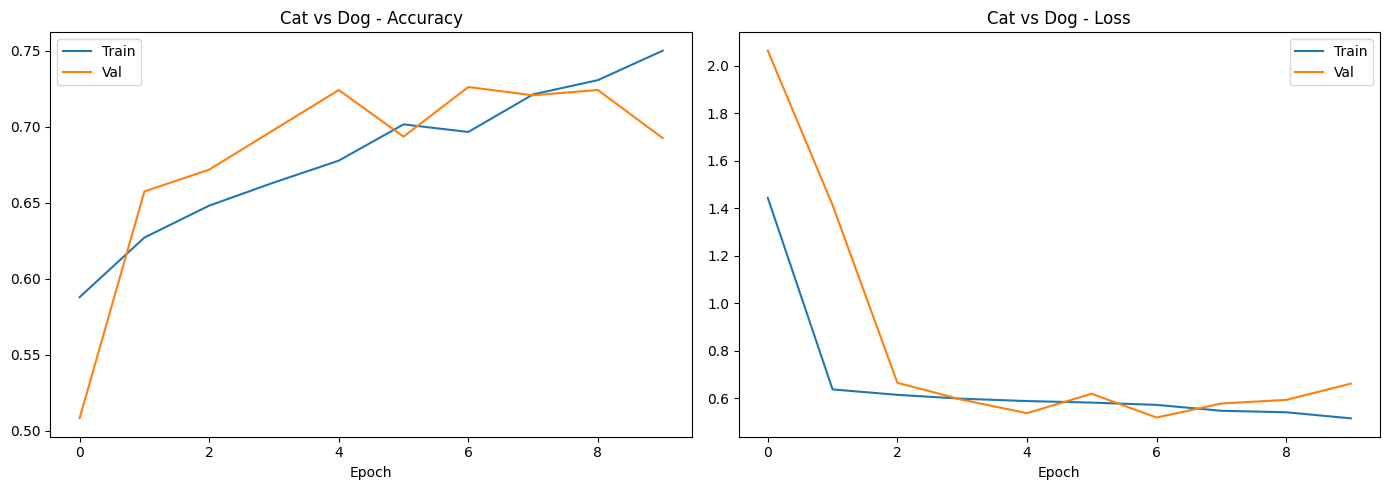

In [7]:
import matplotlib.pyplot as plt

# Đánh giá & vẽ biểu đồ Cat vs Dog
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_cd.history['accuracy'],     label='Train')
ax1.plot(history_cd.history['val_accuracy'], label='Val')
ax1.set_title('Cat vs Dog - Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history_cd.history['loss'],     label='Train')
ax2.plot(history_cd.history['val_loss'], label='Val')
ax2.set_title('Cat vs Dog - Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

Vui lòng chọn một bức ảnh để kiểm tra


Saving Untitled.jpg to Untitled.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 945ms/step


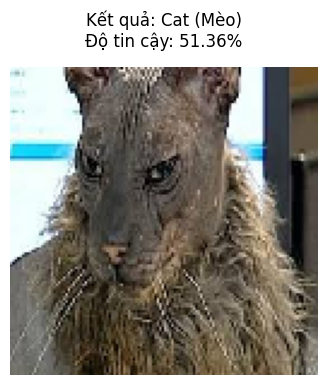

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

def predict_uploaded_image(model):
    print("Vui lòng chọn một bức ảnh để kiểm tra")
    uploaded = files.upload()

    for fn in uploaded.keys():
        # Lấy đường dẫn file vừa tải lên
        path = '/content/' + fn

        #Load ảnh và thay đổi kích thước về 128x128 để khớp với input của model
        img = image.load_img(path, target_size=IMG_SIZE_CD)

        #Chuyển ảnh thành mảng numpy
        img_array = image.img_to_array(img)

        # Chuẩn hóa dữ liệu (giống với rescale=1./255 trong lúc train)
        img_array = img_array / 255.0

        # Thêm một chiều (batch dimension) vì model yêu cầu input là (batch_size, height, width, channels)
        img_array = np.expand_dims(img_array, axis=0)

        # dự đoán
        prediction = model.predict(img_array)

        # Phân tích kết quả (Hàm sigmoid trả về giá trị từ 0 đến 1)
        # < 0.5 là Class 0 (Cat), >= 0.5 là Class 1 (Dog)
        if prediction[0][0] >= 0.5:
            label = "Dog (Chó)"
            confidence = prediction[0][0] * 100
        else:
            label = "Cat (Mèo)"
            confidence = (1 - prediction[0][0]) * 100

        # Hiển thị ảnh với kết quả
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Kết quả: {label}\nĐộ tin cậy: {confidence:.2f}%", pad=15)
        plt.show()

# Gọi hàm và truyền model vừa huấn luyện vào
predict_uploaded_image(model_cd)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train shape: (60000, 28, 28, 1)


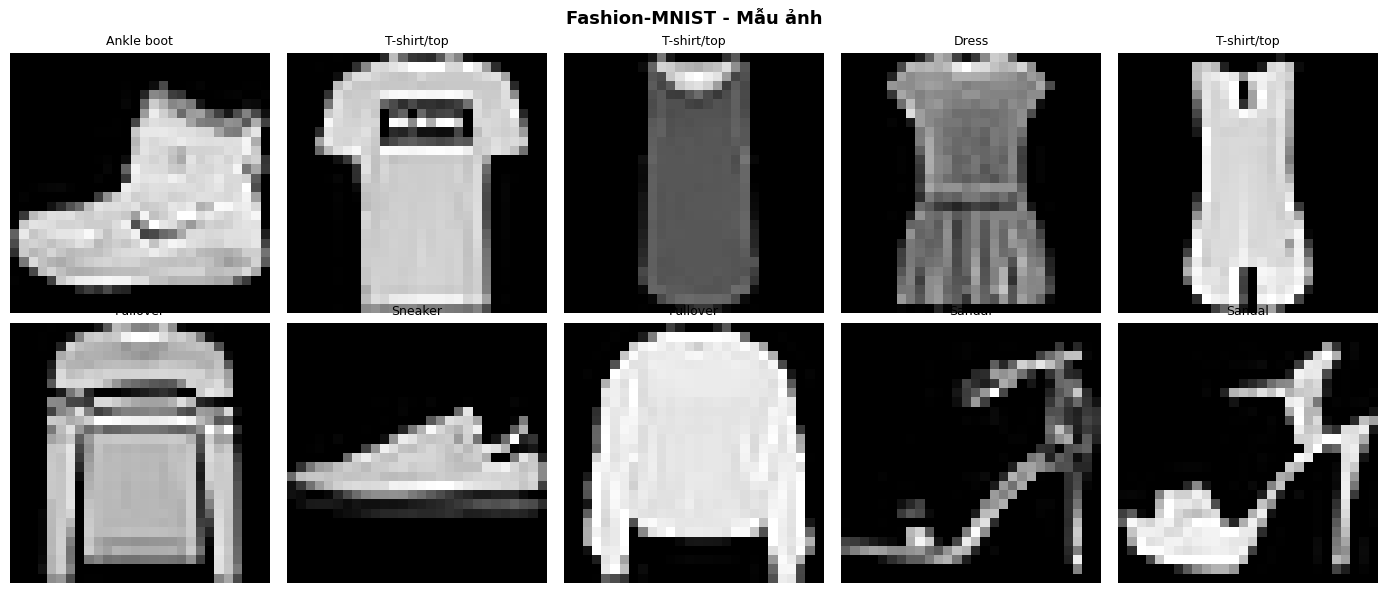

In [10]:
import tensorflow.keras as keras

# BÀI 3: FASHION-MNIST

CLASS_NAMES_FM = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# dữ liệu trong Keras
(X_train_fm, y_train_fm), (X_test_fm, y_test_fm) = keras.datasets.fashion_mnist.load_data()

# Tiền xử lý
X_train_fm = X_train_fm.astype('float32') / 255.0
X_test_fm  = X_test_fm.astype('float32') / 255.0
X_train_fm = X_train_fm.reshape(-1, 28, 28, 1)
X_test_fm  = X_test_fm.reshape(-1, 28, 28, 1)

y_train_fm_cat = keras.utils.to_categorical(y_train_fm, 10)
y_test_fm_cat  = keras.utils.to_categorical(y_test_fm,  10)

print('X_train shape:', X_train_fm.shape)

# Trực quan hóa
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train_fm[i].reshape(28,28), cmap='gray')
    ax.set_title(CLASS_NAMES_FM[y_train_fm[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Fashion-MNIST - Mẫu ảnh', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [11]:
# Xây dựng & huấn luyện CNN cho Fashion-MNIST
model_fm = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_fm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fm.summary()

history_fm = model_fm.fit(
    X_train_fm, y_train_fm_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.7728 - loss: 0.6340 - val_accuracy: 0.5040 - val_loss: 2.0446
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8464 - loss: 0.4251 - val_accuracy: 0.8873 - val_loss: 0.2988
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8634 - loss: 0.3734 - val_accuracy: 0.8955 - val_loss: 0.2801
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8764 - loss: 0.3381 - val_accuracy: 0.9043 - val_loss: 0.2615
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8852 - loss: 0.3182 - val_accuracy: 0.9028 - val_loss: 0.2597
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8888 - loss: 0.3069 - val_accuracy: 0.9090 - val_loss: 0.2517
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8926 - loss: 0.2923 - val_accuracy: 0.9100 - val_loss: 0.2536
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8966 - loss: 0.2799 - val_accuracy: 

[Fashion-MNIST] Test Loss    : 0.2286
[Fashion-MNIST] Test Accuracy: 92.22%
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step


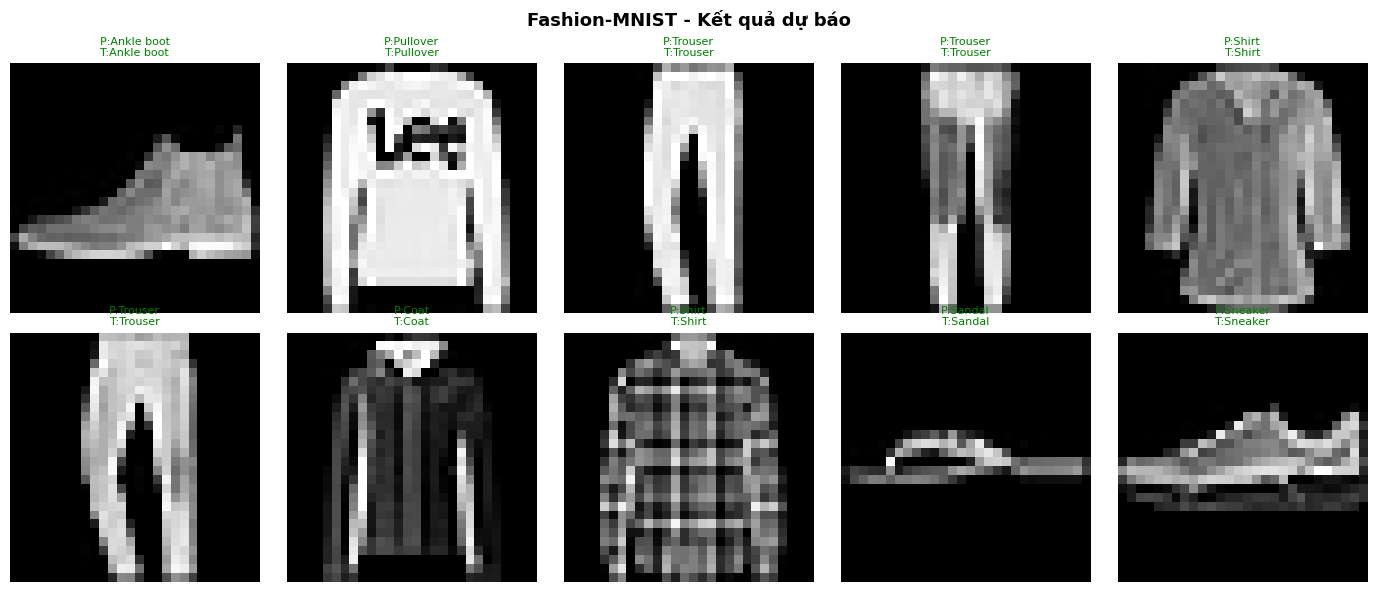

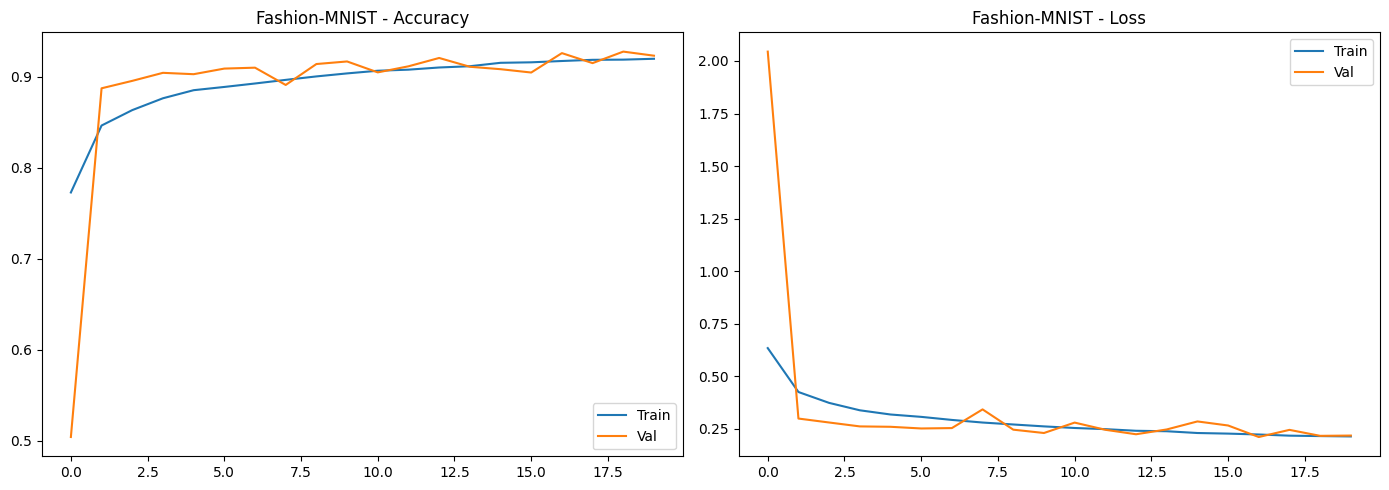

In [12]:
# Đánh giá Fashion-MNIST
score_fm = model_fm.evaluate(X_test_fm, y_test_fm_cat, verbose=0)
print(f'[Fashion-MNIST] Test Loss    : {score_fm[0]:.4f}')
print(f'[Fashion-MNIST] Test Accuracy: {score_fm[1]*100:.2f}%')

# Dự báo và hiển thị
preds_fm = model_fm.predict(X_test_fm[:10])
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_fm[i].reshape(28,28), cmap='gray')
    pred  = CLASS_NAMES_FM[np.argmax(preds_fm[i])]
    true  = CLASS_NAMES_FM[y_test_fm[i]]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'P:{pred}\nT:{true}', color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Fashion-MNIST - Kết quả dự báo', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Vẽ accuracy/loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_fm.history['accuracy'],     label='Train')
ax1.plot(history_fm.history['val_accuracy'], label='Val')
ax1.set_title('Fashion-MNIST - Accuracy'); ax1.legend()
ax2.plot(history_fm.history['loss'],     label='Train')
ax2.plot(history_fm.history['val_loss'], label='Val')
ax2.set_title('Fashion-MNIST - Loss'); ax2.legend()
plt.tight_layout(); plt.show()